In [1]:
import numpy as np
import sys, os
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
from SpaceBalls.sph_meshing import QuadratureGrid
from SpaceBalls.plotter import Plotter
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays
EEI_name = "EEI_truth_0"

grid = QuadratureGrid(alt_km=800, order=131)
frame = 'SFF'
frame_tag = '_SFF_accurate' if frame=="SFF" else ''

n_days = 1826
grid_point_idx = 500 #1500

true_net_Fr = np.concatenate([np.load(os.path.join(MEDIA_DIR, 'true_EEI', EEI_name, grid.grid_name,
                                                   'daily_hist_net_Fr_800km'+frame_tag, 
                                                   'day_'+str(i)+'.npy'), mmap_mode='r')[grid_point_idx,:]
                                                   for i in range(n_days)])

day_jd_hist = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name)[:n_days])



In [3]:
from SpaceBalls.postproc_EEI_estimation import get_full_output_var_hist, get_radial_measurement_arrays
from SpaceBalls.sph_meshing import QuadratureGrid

input_names = ['7b54acc8701b0625','82c0c7e77260bb76','c1dd568b730da76c']
n_sb = len(input_names)
alt = 800
grid = QuadratureGrid(alt_km=alt, order=131)


jd_hist_array = get_full_output_var_hist(input_names, 'jd_vec')
radial_flux_meas_arrays, weight_meas_arrays = get_radial_measurement_arrays(input_names, grid, 
                                                           method='hanning_3', #'binary_gridding',
                                                           frame=frame, meas='flux', 
                                                           meas_mode='recomp_radial')
weight_meas_arrays = [weight_array[grid_point_idx,:][None,:] for weight_array in weight_meas_arrays]

r_file_tag = '_ecef' if frame=="ECEF" else '_sun_frame'
r_hist_array = get_full_output_var_hist(input_names, 'xyz'+r_file_tag)

all_meas_arrays = [None] * n_sb # with zeroes
all_meas_arrays_nodF = [None] * n_sb # with zeroes
all_meas_on_cell = [None] * n_sb
all_meas_on_cell_jd = [None] * n_sb
all_delta_r = [None] * n_sb
all_delta_Fr = [None] * n_sb

for i, sb in enumerate(input_names):
    jd_hist = jd_hist_array[i]
    meas_array = radial_flux_meas_arrays[i][grid_point_idx,:]

    meas_idxs = meas_array.nonzero()[0]
    all_meas_on_cell_jd[i] = jd_hist[meas_idxs]
    all_delta_r[i] = r_hist_array[i][meas_idxs,:] - grid.stacked_grid_r[grid_point_idx,:]
    # MAKE MOVING AVG PLOT OF DELTA R COMPONENTS
    truth_at_meas_times = np.interp(all_meas_on_cell_jd[i], day_jd_hist, true_net_Fr)
  
    meas_array_corrected = meas_array.copy()
    meas_array_corrected.data = truth_at_meas_times
    all_meas_arrays_nodF[i] = meas_array_corrected[None,:]
    
    all_meas_arrays[i]  = meas_array[None,:]
    all_meas_on_cell[i] = meas_array.data

    all_delta_Fr[i] = all_meas_on_cell[i] - truth_at_meas_times



Getting output variable: jd_vec


Getting output variable: jd_vec
Getting output variable: jd_vec
Getting r_hist_array...
Getting output variable: xyz_sun_frame
Getting output variable: xyz_sun_frame
Getting output variable: xyz_sun_frame
Getting output variable: srp_recomp_radial
Getting output variable: srp_recomp_radial
Getting output variable: srp_recomp_radial
Getting output variable: erp_recomp_radial
Getting output variable: erp_recomp_radial
Getting output variable: erp_recomp_radial
Getting output variable: aero
Getting output variable: aero
Getting output variable: aero
Getting output variable: srp
Getting output variable: srp
Getting output variable: srp
Getting output variable: erp
Getting output variable: erp
Getting output variable: erp
Getting output variable: aero
Getting output variable: aero
Getting output variable: aero
Computing sparse arrays for sc 0
Shape all_radial_measurement_arrays[sc_i]: (10517760,)
Shape r_hist_array[sc_i]: (10517760, 3)
Computing sparse arrays for sc 1
Shape all_radial_measu

In [5]:
from SpaceBalls.postproc_EEI_estimation import get_all_jd_windows, get_stacked_avg_maps_new

window_days = 365
jd_windows = get_all_jd_windows(EEI_name, window_days)
meas_avg = get_stacked_avg_maps_new(jd_windows, jd_hist_array, all_meas_arrays, weight_meas_arrays)
meas_avg_nodF = get_stacked_avg_maps_new(jd_windows, jd_hist_array, all_meas_arrays_nodF, weight_meas_arrays)

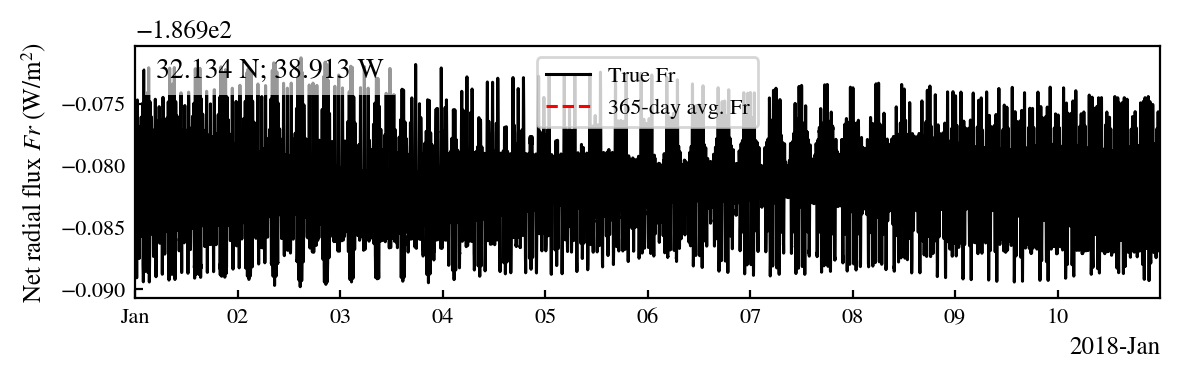

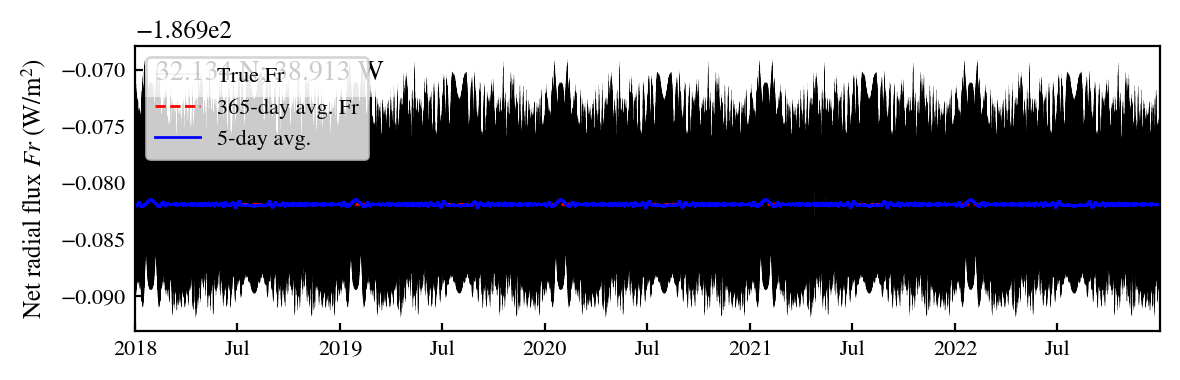

In [6]:
from importlib import reload
import SpaceBalls.plotter
# After changing my_module.py, run this:
reload(SpaceBalls.plotter)
from SpaceBalls.plotter import Plotter
reload(SpaceBalls.utils)
from SpaceBalls.utils import normal_smoother, latlon_to_coord_name
cell_name = latlon_to_coord_name(grid.stacked_grid_latlon[grid_point_idx,:])


rolling_avg = normal_smoother(true_net_Fr, day_jd_hist, window_days, 
                              out_length_mode='same_with_nans')
rolling_avg_5days = normal_smoother(true_net_Fr, day_jd_hist, 5, 
                              out_length_mode='same_with_nans')

n_days_short = 10
n_steps_short = n_days_short * 1440
fig_short, ax_short = Plotter.plot_time_series(day_jd_hist[:n_steps_short], 
                                               {'True Fr': true_net_Fr[:n_steps_short],
                                       str(window_days)+'-day avg. Fr': rolling_avg[:n_steps_short],
                                       }, 
                                       ylabel='Net radial flux $Fr$ (W/m$^2$)',
                                       f_width=1.5, f_height=0.5, 
                                       col_array=['k', 'r'],
                                       note_top_left=cell_name)


fig, ax = Plotter.plot_time_series(day_jd_hist, {'True Fr': true_net_Fr,
                                       str(window_days)+'-day avg. Fr': rolling_avg,
                                       '5-day avg.': rolling_avg_5days,
                                       }, 
                                       ylabel='Net radial flux $Fr$ (W/m$^2$)',
                                       f_width=1.5, f_height=0.5, lw_array=[0.035, 1, 1], 
                                       col_array=['k', 'r', 'b'],
                                       note_top_left=cell_name)

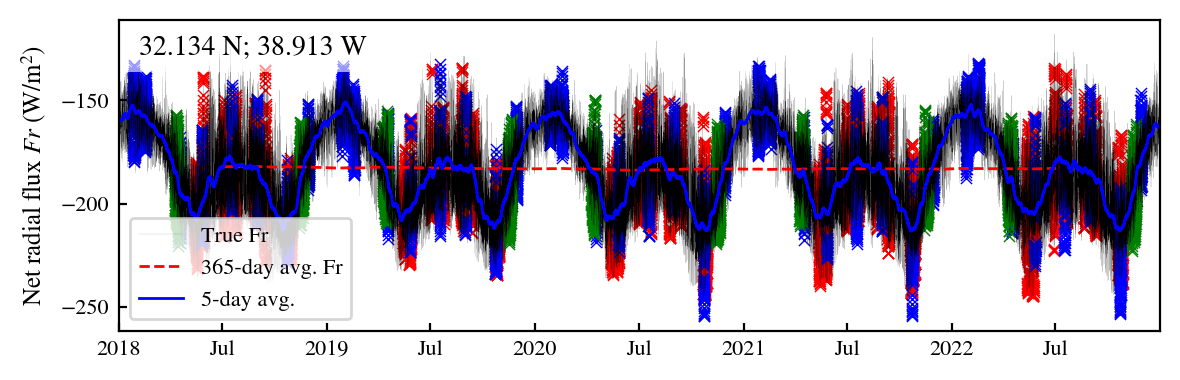

In [11]:
cols = ['r', 'b', 'g']
for i in range(n_sb):
    ax.scatter(Plotter.jd_to_datetime(all_meas_on_cell_jd[i]), all_meas_on_cell[i],
               lw=0.5, marker='x', color=cols[i])
    for jd in all_meas_on_cell_jd[i]:
        pass
        #ax.axvline(Plotter.jd_to_datetime(jd), color=cols[i], lw=0.02)
fig


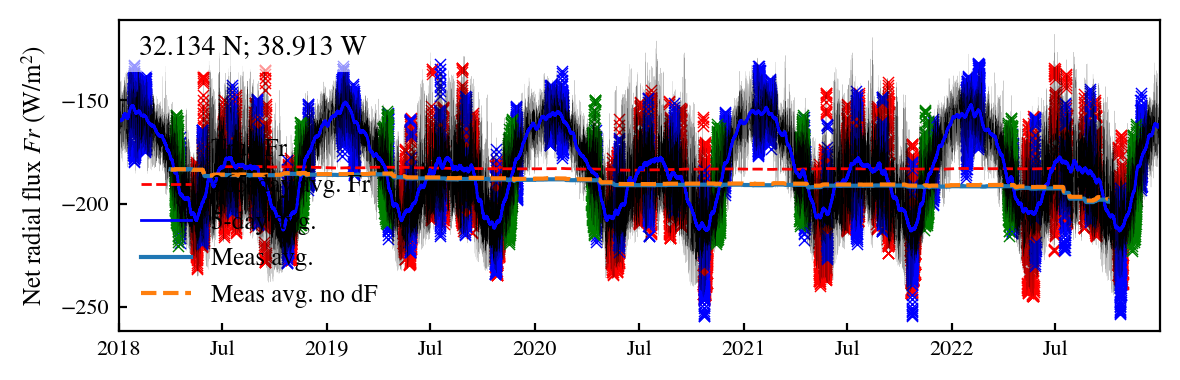

In [12]:
mid_day_jd_vec = np.mean(jd_windows, axis=1)
ax.plot(Plotter.jd_to_datetime(mid_day_jd_vec), meas_avg, label='Meas avg.')
ax.plot(Plotter.jd_to_datetime(mid_day_jd_vec), meas_avg_nodF, label='Meas avg. no dF', linestyle='--')
ax.legend()
fig

(<Figure size 800x800 with 1 Axes>, <Axes: >)

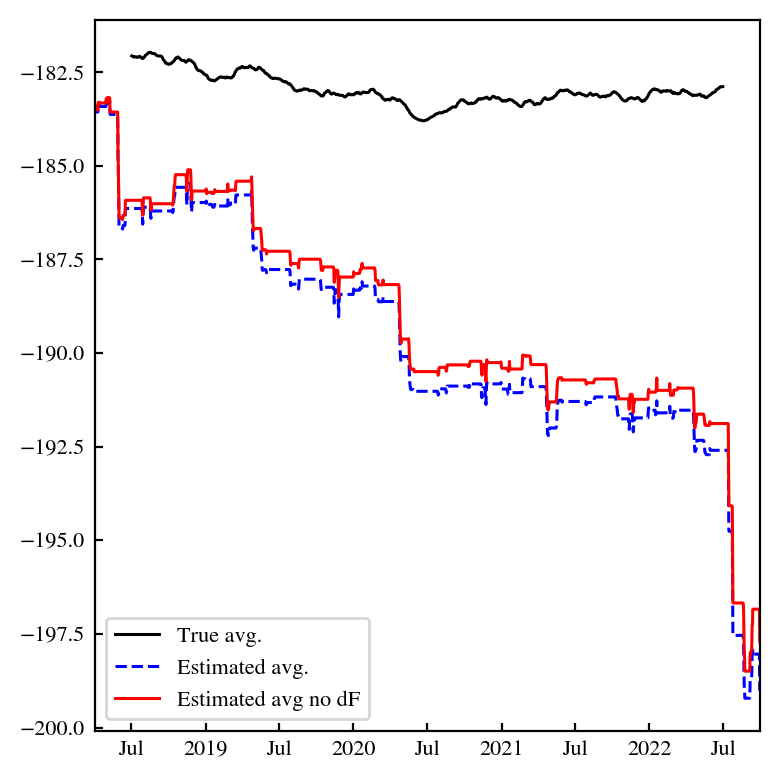

In [13]:
rolling_avg_coarse = np.interp(mid_day_jd_vec, day_jd_hist, rolling_avg)

Plotter.plot_time_series(mid_day_jd_vec, {'True avg.': rolling_avg_coarse,
                                          'Estimated avg.': meas_avg,
                                          'Estimated avg no dF': meas_avg_nodF})

In [ ]:
for r_hist in r_hist_array:
    pass

KeyboardInterrupt: 

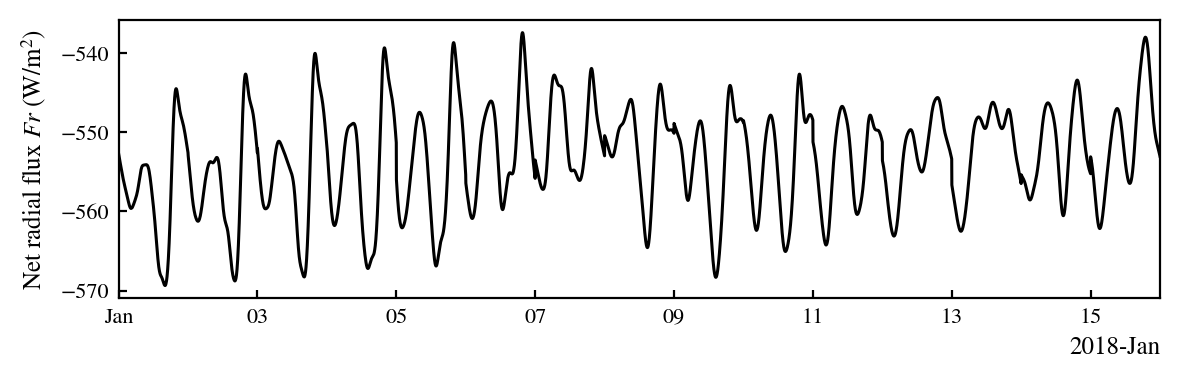

In [11]:
fig2, ax2 = Plotter.plot_time_series(day_jd_hist[:(1440*15)], 
                         {'True Fr': true_net_Fr[:(1440*15)]}, 
                         ylabel='Net radial flux $Fr$ (W/m$^2$)',
                         f_width=1.5, f_height=0.5)

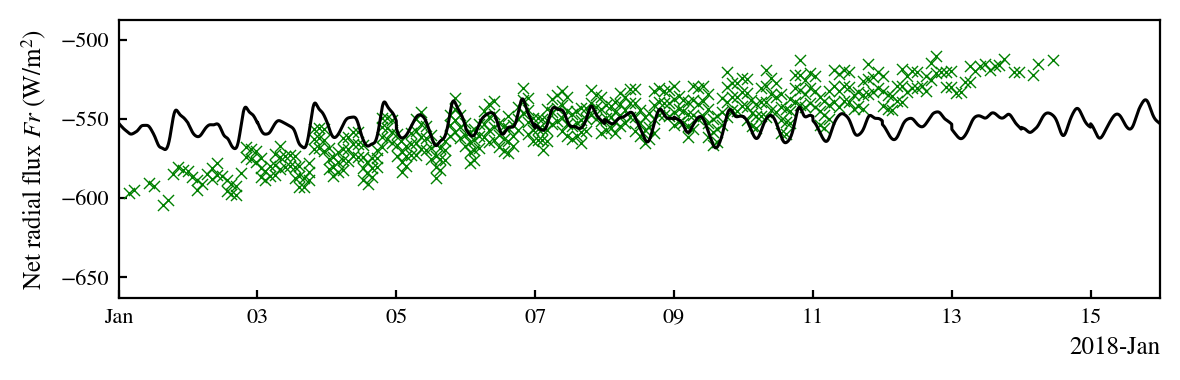

In [12]:
cols = ['r', 'b', 'g']
for i in range(n_sb):
    ax2.scatter(Plotter.jd_to_datetime(all_meas_on_cell_jd[i]), all_meas_on_cell[i],
               lw=0.5, marker='x', color=cols[i])
    for jd in all_meas_on_cell_jd[i]:
        pass
        #ax.axvline(Plotter.jd_to_datetime(jd), color=cols[i], lw=0.02)
fig2

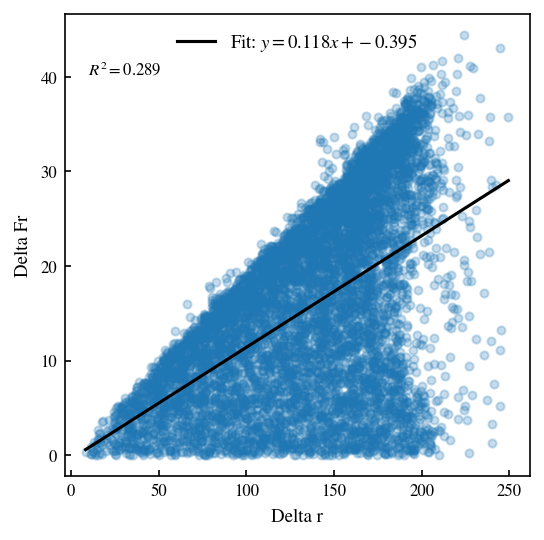

/home/llbu9955/Space-Balls-MST/sbfinal-master/src/SpaceBalls/plotter.py:1051: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=cls.font_size)


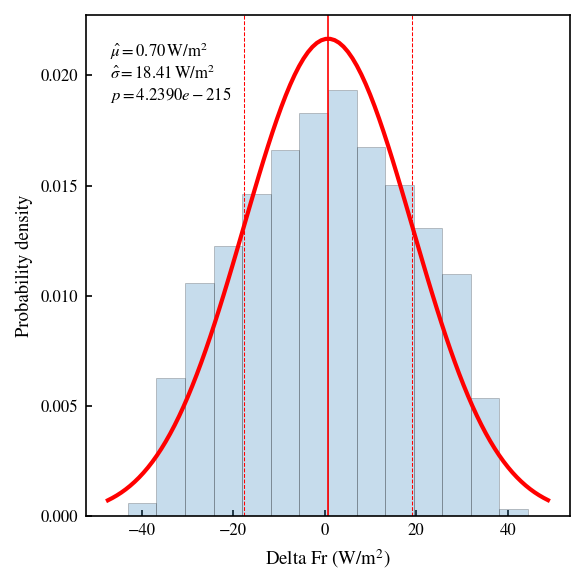

In [13]:
import SpaceBalls.plotter
# After changing my_module.py, run this:
reload(SpaceBalls.plotter)
from SpaceBalls.plotter import Plotter
from SpaceBalls.utils import normal_smoother

all_delta_r_norm = [np.linalg.norm(delta_r, axis=1) for delta_r in all_delta_r]
Plotter.plot_linear_regression(np.concatenate(all_delta_r_norm), 
                               np.abs(np.concatenate(all_delta_Fr)), 
                               xlabel='Delta r', ylabel='Delta Fr')
Plotter.plot_histogram(np.concatenate(all_delta_Fr), xlabel='Delta Fr', normalized=True, 
                       fit_normal=True, units='W/m$^2$')

In [14]:
all_meas_arrays_dense = [np.squeeze(ar.todense()) for ar in all_meas_arrays]
#Plotter.plot_time_series(jd_hist_array[1], {'a': all_meas_arrays_dense[1]}, ylabel='aa', f_width=3)

# assert all jd arrays are equal
counts = np.count_nonzero(np.stack(all_meas_arrays_dense), axis=0) #np.sum(np.asarray(all_meas_arrays_dense, dtype=bool), axis=0, dtype=int)
counts[counts==0]=1
avg_meas_with_zeroes = np.sum(all_meas_arrays_dense, axis=0) / counts
#Plotter.plot_time_series(jd_hist_array[1], {'a': avg_meas_with_zeroes}, ylabel='aa', f_width=3)


meas_filter = np.sum(all_meas_arrays_dense, axis=0, dtype=bool)
#Plotter.plot_time_series(jd_hist_array[0], {'a': meas_filter}, ylabel='aa', f_width=3)



<>:48: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:54: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:48: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:54: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_368734/3152363965.py:48: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.loglog(f_noise, A_noise, color='m', lw=0.2, alpha=0.5, label='Gaussian noise\n$\sigma=17$ W/m$^2$')
/tmp/ipykernel_368734/3152363965.py:54: SyntaxWarning: "\D" is an invalid escape sequence. 

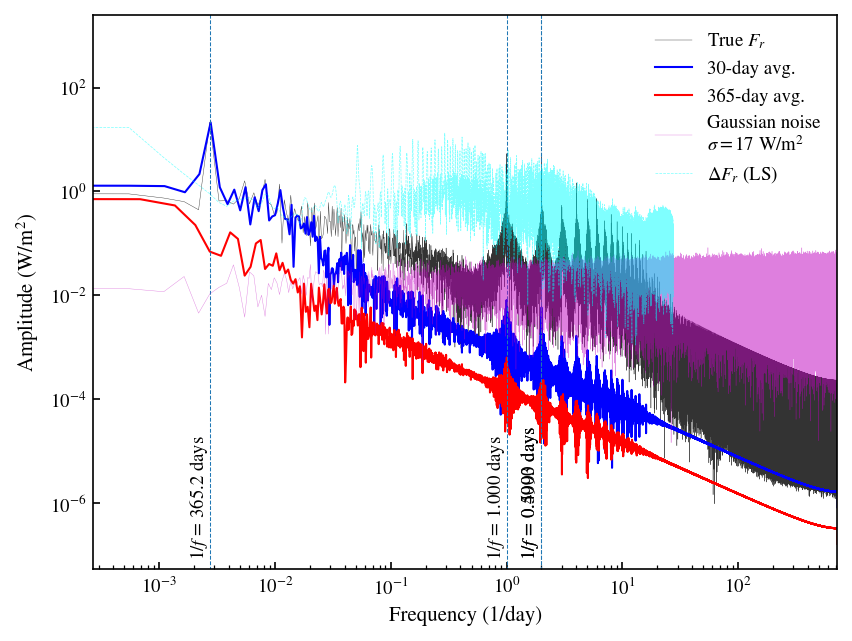

In [15]:
import scipy.fft
import scipy.signal
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import scipy.fft
import SpaceBalls.utils
reload(SpaceBalls.utils)
from SpaceBalls.utils import get_fft_spectrum


fft_f, fft_A, fft_P, fft_PSD = get_fft_spectrum(true_net_Fr, day_jd_hist)

#fft_f_measf, fft_A_measf, fft_P_measf, fft_PSD_measf = get_fft_spectrum(meas_filter, jd_hist_array[0])
fft_f_measf, fft_A_measf, fft_P_measf, fft_PSD_measf = get_fft_spectrum(avg_meas_with_zeroes, jd_hist_array[0])


fft_f_avg, fft_A_avg, fft_P_avg, fft_PSD_avg = get_fft_spectrum(rolling_avg, day_jd_hist)


rolling_avg_30days = normal_smoother(true_net_Fr, day_jd_hist, 30, 
                              out_length_mode='same_with_nans')
fft_f_avg30, fft_A_avg30, fft_P_avg30, fft_PSD_avg30 = get_fft_spectrum(rolling_avg_30days, day_jd_hist)



plt.loglog(fft_f, fft_A, color='k', lw=0.2, alpha=0.8, label='True $F_r$')
plt.loglog(fft_f_avg30, fft_A_avg30, color='b', lw=1, alpha=1, label='30-day avg.')
plt.loglog(fft_f_avg, fft_A_avg, color='r', lw=1, alpha=1, label='365-day avg.')
#plt.loglog(fft_f_measf, fft_A_measf, color='b', lw=0.2, alpha=0.75)
plt.xlabel('Frequency (1/day)')
plt.ylabel('Amplitude (W/m$^2$)')
plt.xlim([np.min(fft_f), np.max(fft_f)])

peaks, props = scipy.signal.find_peaks(fft_A, height=0.1, prominence=0.05)
peaks_sorted = peaks[np.argsort(props['peak_heights'])[-4:]]

y_min, y_max = plt.gca().get_ylim()
for peak_idx in peaks_sorted:
    plt.vlines(fft_f[peak_idx], ymin=0, ymax=1e5, linestyles='--', lw=0.5)
    f_label = f"  $1/f$ = {1/fft_f[peak_idx]:#.4g} days  " 
    plt.text(fft_f[peak_idx], y_min, f_label, 
             ha='right', va='bottom', fontsize=9, rotation=90)
    
noise_time_series = np.random.randn(len(day_jd_hist)) * 17 -0.5
f_noise, A_noise, _, _ = get_fft_spectrum(noise_time_series, day_jd_hist)
plt.loglog(f_noise, A_noise, color='m', lw=0.2, alpha=0.5, label='Gaussian noise\n$\sigma=17$ W/m$^2$')

pgram = scipy.signal.lombscargle(np.concatenate(all_meas_on_cell_jd), 
                                 np.concatenate(all_delta_Fr), 
                                 f_noise[:50000], normalize="amplitude", floating_mean=True)
plt.loglog(f_noise[:50000], np.abs(pgram), linestyle='--', color='cyan', lw=0.35, alpha=0.5, 
           label=f"$\Delta F_r$ (LS)")


plt.legend(loc='upper right')


    


In [16]:

cols=['r', 'b', 'g']
for i in range(3):
    delta_Fr = all_delta_Fr[i]
    jd_meas = all_meas_on_cell_jd[i]
    #f_vec, A_vec, _, _ = get_fft_spectrum(delta_Fr, jd_meas)
    pgram = scipy.signal.lombscargle(jd_meas, delta_Fr, f_noise[:5000], normalize="amplitude")
    plt.loglog(f_noise[:5000], np.abs(pgram), linestyle='--', color=cols[i-1], lw=0.8, alpha=0.5, label=f"$\Delta F_r$ SB {i}")

plt.legend(loc='best')

<>:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_368734/3925171751.py:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.loglog(f_noise[:5000], np.abs(pgram), linestyle='--', color=cols[i-1], lw=0.8, alpha=0.5, label=f"$\Delta F_r$ SB {i}")
/tmp/ipykernel_368734/3925171751.py:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.loglog(f_noise[:5000], np.abs(pgram), linestyle='--', color=cols[i-1], lw=0.8, alpha=0.5, label=f"$\Delta F_r$ SB {i}")


ValueError: Parameters x, y, weights must be 1-D arrays of equal non-zero length!

In [ ]:
pgram = scipy.signal.lombscargle(np.concatenate(all_meas_on_cell_jd), 
                                 np.concatenate(all_delta_Fr), 
                                 f_noise[:15000], normalize="amplitude")
plt.loglog(f_noise[:15000], np.abs(pgram), linestyle='--', color=cols[i-1], lw=0.8, alpha=0.5, label=f"$\Delta F_r$ SB {i}")


In [ ]:

noise_time_series = np.random.randn(10)
noise_time_series

In [ ]:
from SpaceBalls.utils import normal_smoother


ifft = scipy.fft.ifft(scipy.fft.fft(true_net_Fr) * 
                      scipy.fft.fft(window)) 
ifft_1yr_avg = np.real(ifft)
actual_1yr_avg = normal_smoother(true_net_Fr, day_jd_hist, window_width_days=365,
                                 out_length_mode='same_with_nans')

ifft_1yr_avg = np.roll(ifft_1yr_avg, -365*1440 // 2)

Plotter.plot_time_series(day_jd_hist, {'Actual avg': actual_1yr_avg,
                                       'IFFT result': ifft_1yr_avg},
                                       f_width=2.5)

In [ ]:
import numpy as np
import scipy.signal
import scipy.fft
import matplotlib.pyplot as plt

# -----------------------------
# Create a signal
# -----------------------------
N = 512
t = np.linspace(0, 10, N)

signal = (
    np.sin(2*np.pi*1.5*t)
    + 0.5*np.sin(2*np.pi*8*t)
    + 0.3*np.random.randn(N)
)

# -----------------------------
# Create smoothing window
# -----------------------------
window_size = 25

signal = true_net_Fr
N = len(signal)
window_size = 30*1440
t = day_jd_hist

window = np.ones(window_size)
window /= window.sum()   # normalize

# -----------------------------
# Direct convolution
# -----------------------------
smoothed_conv = scipy.signal.fftconvolve(signal, window, mode='same')

# -----------------------------
# FFT convolution theorem
# -----------------------------
# Zero-pad window to signal length
window_padded = np.zeros(N)
window_padded[:window_size] = window


# FFTs
signal_fft = scipy.fft.fft(signal)
window_fft = scipy.fft.fft(window_padded)


# Multiply in Fourier domain
product_fft = signal_fft * window_fft

# Inverse FFT
smoothed_fft = scipy.fft.ifft(product_fft).real

# Circular shift correction
smoothed_fft = np.roll(smoothed_fft, -window_size // 2)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(t, signal, alpha=0.4, label='Original signal')
plt.plot(t, smoothed_conv, linewidth=2, label='Direct convolution')
plt.plot(t, smoothed_fft, '--', linewidth=2,
         label='FFT theorem result')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Convolution theorem demonstration')

plt.show()